In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import tensorflow as tf
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "not available")

In [ ]:
import pandas as pd
import numpy as np

import ipaddress

In [ ]:
df = pd.concat(
    map(pd.read_csv, 
        ['/kaggle/input/bot-iot-data-set/UNSW_2018_IoT_Botnet_Full5pc_1.csv',
         '/kaggle/input/bot-iot-data-set/UNSW_2018_IoT_Botnet_Full5pc_2.csv',
         '/kaggle/input/bot-iot-data-set/UNSW_2018_IoT_Botnet_Full5pc_3.csv',
         '/kaggle/input/bot-iot-data-set/UNSW_2018_IoT_Botnet_Full5pc_4.csv']), 
    ignore_index=True)

In [ ]:
df['stime'] = df['stime'].astype('int64') 
df['ltime'] = df['ltime'].astype('int64') 

#taking important features
df = df[['spkts','dpkts','sbytes','dbytes','dur','proto','attack','stime','ltime','sport','dport','saddr','daddr','category']]

df.head()

In [ ]:
df['saddr'] =  df['saddr'].apply(lambda x:int(ipaddress.ip_address(x)))
df['daddr'] =  df['daddr'].apply(lambda x:int(ipaddress.ip_address(x)))

df.head()

In [ ]:
df['proto'].value_counts()

In [ ]:
df = df[(df['proto']=='udp') | (df['proto']=='tcp')]

#replacing udp with 0 and tcp with 1
df['proto'] = np.where(df['proto'] == 'udp', 0, 1)

df['category'].value_counts()


#we only need  attack category of dos and ddos type
df = df[(df['category']=='DDoS') | (df['category']=='DoS')]

#resetting index
df.reset_index(drop=True,inplace=True)

df

In [ ]:
# import os

# # Create the directory if it doesn't exist
# os.makedirs('kaggle/input/datasets', exist_ok=True)

# # Now you can save your CSV files
# df_dos_train.to_csv('kaggle/input/datasets/bot_iot_dos.csv',index=False)
# df_dos_test.to_csv('kaggle/input/datasets/bot_iot_dos.csv',index=False)

In [ ]:
#splitting data of category Dos into train and test
df_dos = df[df['category'] == 'DoS']
df_dos_train = df_dos.iloc[:1600000]
df_dos_test = df_dos.iloc[1641197:]

In [ ]:
df_dos_train.to_csv("train.csv", index=False)  # Assuming 'index=False' for desired output

df_dos_test.to_csv("test.csv", index=False)  # Assuming 'index=False' for desired output

In [ ]:
df_ddos = df[df['category'] == 'DDoS']
df_ddos.reset_index(drop= True,inplace = True)
df_ddos_train = df_ddos.iloc[:1600000]
df_ddos_test = df_ddos.iloc[1917572:]

In [ ]:
df_ddos_train.to_csv("ddostrain.csv",index=False)
df_ddos_test.to_csv("ddostest.csv",index=False)

In [ ]:
df2 = pd.read_csv("/kaggle/input/unsw-nb15/UNSW-NB15_1.csv")

In [ ]:
df_name = pd.read_csv("/kaggle/input/unsw-nb15/NUSW-NB15_features.csv",sep=",", encoding='cp1252')
columnn_name = df_name['Name']

df2.columns = columnn_name

In [ ]:
df2['attack_cat'].fillna('Normal', inplace=True)

In [ ]:
df2['attack_cat'].value_counts()

In [ ]:
df2= df2[['Spkts','Dpkts','sbytes','dbytes','dur','proto','Label','Stime','Ltime','sport','dsport','srcip','dstip','attack_cat']]
#replacing the column names with proper name
df2.rename(columns = {'Spkts':'spkts','Dpkts':'dpkts','Label':'attack','Stime':'stime','Ltime':'ltime','sport':'sport','dsport':'dport','srcip':'saddr','dstip':'daddr','attack_cat':'category'}, inplace = True)

In [ ]:
df2['saddr'] =  df2['saddr'].apply(lambda x:int(ipaddress.ip_address(x)))
df2['daddr'] =  df2['daddr'].apply(lambda x:int(ipaddress.ip_address(x)))

In [ ]:
df2 = df2[(df2['proto']=='udp') | (df2['proto']=='tcp')]

#replacing udp with 0 and tcp with 1
df2['proto'] = np.where(df2['proto'] == 'udp', 0, 1)

In [ ]:
# df2 = df2[df2['category']=='Normal']
# df2.reset_index(drop=True,inplace=True)

In [ ]:
df2.iloc[:160000].value_counts

In [ ]:
df_train = df2.iloc[:160000]  # Calculate value counts
df_train.to_csv('testunsw_normal.csv', index=False)  # Save value counts to a CSV file

In [ ]:
# df_train = df2.iloc[:160000].value_counts
# df_train.to_csv('testunsw_normal.csv',index=False)

In [ ]:
df_test = df2.iloc[663637:]
df_test.to_csv('trainunsw_normal.csv',index=False)

In [ ]:
df_unsw_normal = pd.read_csv('/kaggle/working/testunsw_normal.csv')
df_bot_dos = pd.read_csv('/kaggle/working/train.csv')
df_bot_ddos = pd.read_csv('/kaggle/working/ddostrain.csv')

In [ ]:
df_unsw_normal

In [ ]:
df2['category'].value_counts()

In [ ]:
def data_chunks_creater(df_unsw_normal, df_bot_dos, df_bot_ddos):
    dataframe_list=[]
    # we are taking 10 chunks only but you can take maximum upto 20
    number_of_chunks = 10
    data_limit = 2*80000*number_of_chunks

    # chunk_start and chunk_end are used to partition chunks from the oversampled data
    chunk_start = 0
    chunk_end = 2*80000

    # iterating so the chunks could be merged
    for _ in range(number_of_chunks):

        df_unsw_normal = df_unsw_normal

        df_bot_dos = pd.read_csv('/kaggle/working/train.csv')
        df_bot_dos = df_bot_dos.iloc[:data_limit]
        df_bot_dos = df_bot_dos.iloc[chunk_start:chunk_end]

        df_bot_ddos = pd.read_csv('/kaggle/working/ddostrain.csv')
        df_bot_ddos = df_bot_ddos.iloc[:data_limit]
        df_bot_ddos = df_bot_ddos.iloc[chunk_start:chunk_end]

        # merging the data and also shuffling the data and appending the different chunks in a list, this also ensures the
        # the data is still into chunks its well balanced and consistent
        df = pd.concat([df_unsw_normal, df_bot_dos, df_bot_ddos],
                       ignore_index=True, sort=False)
        df = shuffle(df)
        df.reset_index(drop=True, inplace=True)
        dataframe_list.append(df)

        # updating chunk_start and chunk_end value
        chunk_start = chunk_end
        chunk_end = chunk_end+80000*2

    return dataframe_list

In [ ]:
from sklearn.utils import shuffle

In [ ]:
data = data_chunks_creater(df_unsw_normal,df_bot_dos,df_bot_ddos)

class_names = ['DoS','Normal','DDoS']

In [ ]:
data

In [ ]:
# driv

In [ ]:
# driv

In [ ]:
# def data_preprocessing(data):
#     x_label_data = list()
#     y_label_data = list()
#     for subset_data in data:
#         df = subset_data
#         x = df.loc[:, df.columns != 'category']
#         # min_max
#         x = (x-x.min())/(x.max()-x.min())
#         df.category = pd.factorize(df.category)[0]
#         y = df['category']
#         x_label_data.append(x)
#         y_label_data.append(y)
#     return x_label_data, y_label_data

In [ ]:
# x_label_data,y_label_data = data_preprocessing(data)

# #Model Architecture

In [ ]:
import tensorflow as tf

In [ ]:
data = np.array(data).reshape(-1, 14)  # Reshape to flatten the extra dimension

driv = pd.DataFrame(data, columns=[
    "spkts", "dpkts", "sbytes", "dbytes", "dur", "proto", "attack", "stime",
    "daddr", "ltime", "sport", "dport", "saddr", "category"
])

print(driv)

In [ ]:
print(driv['category'].unique())

In [ ]:
driv['category'] = driv['category'].str.strip()  # Remove leading/trailing spaces

In [ ]:
driv['category'].value_counts()

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import KMeansSMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Assuming 'X_train' and 'y_train' are your feature and target variables from the dataset
X_train = driv.drop('category', axis=1)
y_train = driv['category']

# Use KMeansSMOTE to balance the data
kmeans_smote = KMeansSMOTE(random_state=42, n_jobs=2000)
X_resampled, y_resampled = kmeans_smote.fit_resample(X_train, y_train)

# Convert the resampled data to a DataFrame
resampled_data = pd.DataFrame(X_resampled, columns=X_train.columns)
resampled_data['category'] = y_resampled

# Save the resampled data to a CSV file
resampled_data.to_csv('resampled_data.csv', index=False)

# Normalize the numerical features
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)

# Split the data into training and testing sets
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_resampled_scaled, y_resampled, test_size=0.2, random_state=42)

# Initialize the KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Fit the classifier to the training data
knn_classifier.fit(X_train_knn, y_train_knn)

# Predict on the test set
y_pred_knn = knn_classifier.predict(X_test_knn)

# Print the classification report and accuracy score for the KNN classifier
print("K-Nearest Neighbors (KNN) Classifier:")
print(classification_report(y_test_knn, y_pred_knn))
print("Accuracy:", accuracy_score(y_test_knn, y_pred_knn))


In [ ]:
ءءءءءءءءءءءءءءءءءءءءءءءءء

In [ ]:
# import pandas as pd
# from sklearn.preprocessing import LabelEncoder
# from sklearn.model_selection import train_test_split

# # Assuming 'driv' is your DataFrame
# # Perform preprocessing on 'category' column

# # Separate features (X) and target variable (y)
# X = driv.drop('category', axis=1)
# y = driv['category']

# # Label encode the target variable 'category'
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

# # Split the data into training and testing sets
# X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

# # Inverse transform the encoded labels to get the original labels for y_train and y_test
# y_train = label_encoder.inverse_transform(y_train_encoded)
# y_test = label_encoder.inverse_transform(y_test_encoded)

# # Now you can proceed with your preprocessing steps, such as handling missing values, scaling features, etc., using X_train and X_test

In [ ]:
# from sklearn.preprocessing import LabelEncoder
# X2 = driv.drop('category', axis=1)
# y2 = driv['category']

# # Label encode the target variable 'category'
# label_encoder = LabelEncoder()
# y_encoded2 = label_encoder.fit_transform(y2)

In [ ]:
# from sklearn.model_selection import train_test_split
# import pandas as pd
# X = driv.drop('category', axis=1)
# y = driv['category']

# # Assuming you have a DataFrame called 'data' with features and target columns
# # X contains features, y contains the target variable

# # Perform stratified sampling with a 80-20 split
# X_train2, X_test2, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# X_train

In [ ]:
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

# # Split the data into training and testing sets
# X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

# # Convert y_train_encoded back to DataFrame or Series
# y_train = pd.Series(label_encoder.inverse_transform(y_train_encoded), name='category')

# # Concatenate X_train and y_train
# train_data = pd.concat([X_train, y_train], axis=1)

In [ ]:
# driv

In [ ]:
# from sklearn.model_selection import train_test_split
# import pandas as pd
# df3 = df3.dropna(subset=['category'])

# # Separate features (X) and target variable (y)
# X_text = df3['category']  # Assuming 'text_column' contains your text data
# y = df3['category']

# # Tokenize the text data and pad sequences
# tokenizer = Tokenizer()
# tokenizer.fit_on_texts(X_text)
# X_seq = tokenizer.texts_to_sequences(X_text)
# X_padded = pad_sequences(X_seq)

# # Label encode the target variable 'category'
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

# # Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X_padded, y_encoded, test_size=0.2, random_state=42)

In [ ]:
# y_train_series = pd.Series(y_train, name='category')

# # Now you can proceed with your preprocessing steps, su

In [93]:

train_data = pd.concat([X_train, y_train], axis=1)

In [94]:
train_data

,spkts,dpkts,sbytes,dbytes,dur,proto,attack,stime,daddr,ltime,sport,dport,saddr,category
3025471,8,0,480,0,25.000326,0,1,1528084952,1528084977,37579,80,3232261268,3232261126,DoS
3483669,14,18,1684,10168,1.006976,1,0,1421932670,1421932671,4622,80,1000734724,2511044098,Normal
2369607,5,0,770,0,12.277461,1,1,1528095764,1528095777,63375,80,3232261267,3232261123,DDoS
1547138,2,0,264,0,0.000002,0,0,1421931037,1421931037,47439,53,2511044114,2939006977,Normal
3262091,2,2,146,178,0.001105,0,0,1421927756,1421927756,26096,53,1000734726,2511044103,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4396767,42,44,2646,24316,0.013964,1,0,1421931849,1421931849,53921,61321,1000734728,2511044103,Normal
88880,4,0,616,0,25.054943,1,1,1528081325,1528081350,53826,80,3232261267,3232261127,DoS
1472194,34,36,2230,14042,0.032844,1,0,1421927976,1421927976,43305,3461,1000734723,2511044098,Normal
2690924,56,58,3390,41676,0.052046,1,0,1421932318,1421932318,13362,41037,1000734728,2511044100,Normal


In [95]:
majority_class  = ['Normal','Generic','Exploits','Fuzzers','DoS','DDoS','Reconnaissance']
minority_class= ['Analysis','Backdoor','Shellcode','Worms']

# Split the dataset into minority and majority

minority = train_data[train_data['category'].isin(minority_class)].reset_index(drop=True)
majority = train_data[train_data['category'].isin(majority_class)].reset_index(drop=True)

In [ ]:
majority

In [ ]:
# majority.replace([np.inf, -np.inf], np.nan, inplace=True)
# majority.dropna(inplace=True)  # Drop rows with NaN values

In [96]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans

In [97]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors

In [ ]:
# easy['category'].value_counts()

In [98]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors

# Assuming you have already defined train_data, majority, minority, and X_train as in your previous code snippets

# Fit the Nearest Neighbors model
enn = NearestNeighbors(n_neighbors=500)
enn.fit(majority.drop(columns=['category']))

# Find difficult samples
difficult_idx = enn.kneighbors(minority.drop(columns=['category']), return_distance=False).flatten()
difficult_idx_set = set(difficult_idx)  # Convert to a set to remove duplicates
difficult_idx_list = list(difficult_idx_set)  # Convert back to a list for indexing

# Filter indices that are within the range of train_data
valid_indices = [idx for idx in difficult_idx_list if idx < len(train_data)]

# Filter rows based on valid indices
difficult = train_data[train_data.index.isin(valid_indices)].reset_index(drop=True)

# Find easy samples by excluding difficult samples
easy = train_data[~train_data.index.isin(valid_indices)].reset_index(drop=True)

# Verify the shapes of difficult and easy
print("Difficult samples shape:", difficult.shape)
print("Easy samples shape:", easy.shape)

Difficult samples shape: (27899, 14)
Easy samples shape: (3812101, 14)


In [ ]:
# Assuming 'easy' is your DataFrame containing the 'category' column

# Get the unique values of the 'category' column in 'easy'
unique_categories_easy = difficult['category'].unique()

# Print the unique values
print("Unique categories in 'easy':", unique_categories_easy)

In [99]:
# difficult.replace([np.inf, -np.inf], np.nan, inplace=True)
# difficult.dropna(inplace=True)

# Now, you can fit the KMeans model
kmeans = KMeans(n_clusters=100)
kmeans.fit(difficult.drop(columns=['category']))

compressed = pd.DataFrame(kmeans.cluster_centers_, columns=difficult.columns[:-1])
compressed['category'] = 'Normal'

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [100]:
difficult_min = difficult[difficult['category'].isin(minority_class)]
difficult_max = difficult[difficult['category'] == 'Normal']
difficult_range = difficult_max - difficult_min
difficult_samples = pd.DataFrame()

In [ ]:
# Assuming 'easy' is your DataFrame containing the 'category' column

# Get the unique values of the 'category' column in 'easy'
unique_categories_easy = difficult_samples['Label'].unique()

# Print the unique values
print("Unique categories in 'easy':", unique_categories_easy)

In [101]:
for i in range(10):
  r = pd.DataFrame(columns=difficult_min.columns[:-1])
  random_values = np.random.rand(difficult_min.shape[1]-1)
  r.loc[0] = random_values
  dm = difficult_min.iloc[:,:-1]
  sample = dm.add(r, fill_value=0)
  sample['Label'] = minority_class[np.random.randint(0, len(minority_class))]
  difficult_samples = pd.concat([difficult_samples, sample], ignore_index=True)
     

new_train_set = pd.concat([easy, compressed, difficult_min, difficult_samples])
df3 = new_train_set.sample(frac=1).reset_index(drop=True)
     

df3

,spkts,dpkts,sbytes,dbytes,dur,proto,attack,stime,daddr,ltime,sport,dport,saddr,category,Label
0,8,0,480,0,32.834435,0,1,1528084981,1528085014,38470,80,3232261267,3232261127,DoS,NaN
1,7,2,890,120,39.346779,1,1,1528095780,1528095820,40663,80,3232261270,3232261123,DDoS,NaN
2,7,0,420,0,12.131535,0,1,1528099339,1528099351,63852,80,3232261270,3232261123,DDoS,NaN
3,58,56,3494,44030,0.035991,1,0,1421930491,1421930491,21145,63728,1000734723,2511044102,Normal,NaN
4,6,0,360,0,26.6821,0,1,1528084984,1528085011,13954,80,3232261268,3232261126,DoS,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3812426,15,0,900,0,13.664361,0,1,1528099337,1528099351,54442,80,3232261267,3232261123,DDoS,NaN
3812427,54,42,38148,3380,0.044036,1,0,1421928130,1421928130,62808,25,1000734724,2511044105,Normal,NaN
3812428,9,0,540,0,11.495639,0,1,1528099325,1528099336,14347,80,3232261268,3232261123,DDoS,NaN
3812429,2,0,944,0,0.000011,0,0,1421933375,1421933375,1089,514,2939006979,2511044113,Normal,NaN


In [103]:
df3 = df3.drop('Label', axis=1)

KeyError: "['Label'] not found in axis"

Accuracy: 0.9998260416666667
Confusion Matrix:
[[   113      0      0      0      0      0      0      3      0      0
       0]
 [     0     80      0      0      0      0      0      0      0      0
       0]
 [     0      0 320000      0      0      0      0      0      0      0
       0]
 [     0      0      0 320985      6      0      0      3      0      0
       0]
 [     0      0      0     38   7636      6      3      0      9      0
       0]
 [     0      0      0     10     12   7215      0     19      0      0
       0]
 [     0      0      0      0      0      0  13740      0      4      0
       0]
 [     0      0      0      0      4     19      0 286597      0      0
       0]
 [     0      0      0      3      5      6      0     10   3038      0
       0]
 [     0      0      0      0      0      0      0      7      0    383
       0]
 [     0      0      0      0      0      0      0      0      0      0
      46]]


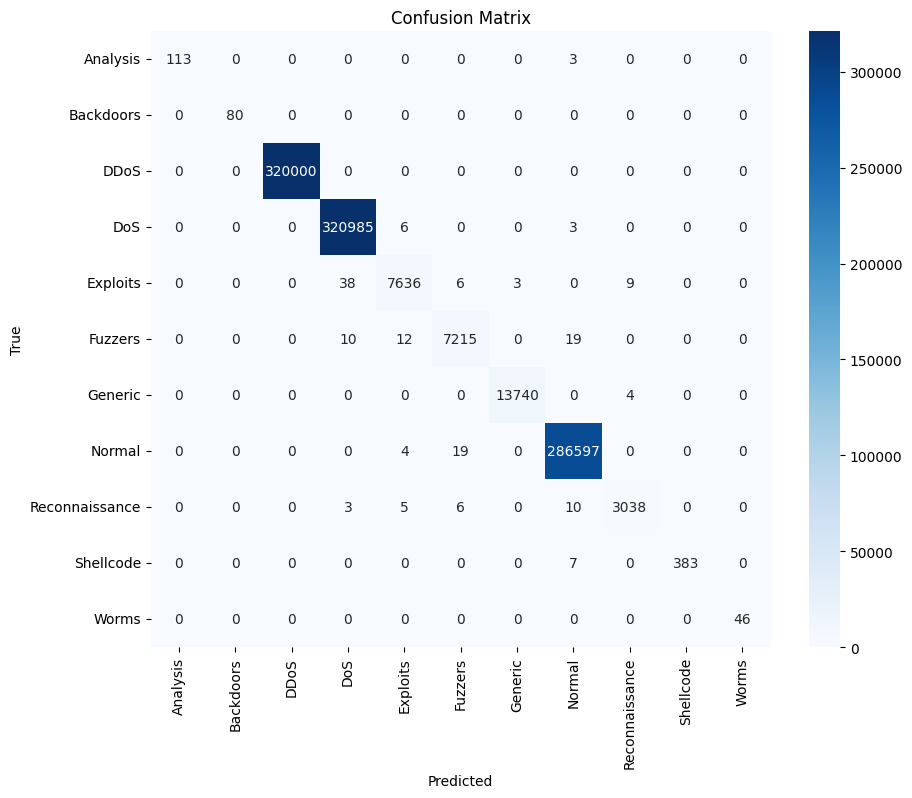

In [104]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

# Assuming 'df3' is your dataframe with NaN values and 'category' is your target column
# Drop rows with missing values in the 'category' column
df3 = df3.dropna(subset=['category'])

# Separate features (X) and target variable (y)
X = df3.drop('category', axis=1)
y = df3['category']

# # Label encode the target variable 'category'
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)
# print(X_train.shape)
# print(y_train2.shape)


# Initialize and train the KNN Classifier
k = 5  # Example: Set the number of neighbors
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train2, y_train2)

# Evaluate the classifier
accuracy = knn.score(X_test, y_test)
print(f"Accuracy: {accuracy}")

# Predict on the test set
y_pred = knn.predict(X_test)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

import matplotlib.pyplot as plt

import seaborn as sns
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

# Assuming 'df3' is your dataframe with NaN values and 'category' is your target column
# Drop rows with missing values in the 'category' column
df3 = df3.dropna(subset=['category'])

# Separate features (X) and target variable (y)
X = df3.drop('category', axis=1)
y = df3['category']

# Label encode the target variable 'category'
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Initialize and train the KNN Classifier
k = 5  # Example: Set the number of neighbors
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Evaluate the classifier
accuracy = knn.score(X_test, y_test)
print(f"Accuracy: {accuracy}")

# Predict on the test set
y_pred = knn.predict(X_test)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

import matplotlib.pyplot as plt

import seaborn as sns
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

# Assuming 'df3' is your dataframe with NaN values and 'category' is your target column
# Drop rows with missing values in the 'category' column
df3 = df3.dropna(subset=['category'])

# Separate features (X) and target variable (y)
X = df3.drop('category', axis=1)
y = df3['category']

# Label encode the target variable 'category'
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_train2.shape)


# Initialize and train the KNN Classifier
k = 5  # Example: Set the number of neighbors
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Evaluate the classifier
accuracy = knn.score(X_test, y_test)
print(f"Accuracy: {accuracy}")

# Predict on the test set
y_pred = knn.predict(X_test)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

import matplotlib.pyplot as plt

import seaborn as sns
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [106]:
pip install keras tensorflow

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 21.6 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: keras
    Found existing installation: keras 3.2.1
    Uninstalling keras-3.2.1:
      Successfully uninstalled keras-3.2.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.8.1 requires wurlitzer, which is not installed.
Note: you may need to restart the kernel to use updated packages.


In [109]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense
from keras.optimizers import Adam
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'df3' is your dataframe with NaN values and 'category' is your target column
# Drop rows with missing values in the 'category' column
df3 = df3.dropna(subset=['category'])

# Separate features (X) and target variable (y)
X_text = df3['category']  # Assuming 'text_column' contains your text data
y = df3['category']

# Tokenize the text data and pad sequences
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_text)
X_seq = tokenizer.texts_to_sequences(X_text)
X_padded = pad_sequences(X_seq)

# Label encode the target variable 'category'
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_padded, y, test_size=0.2, random_state=42)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train2)
y_test_encoded = label_encoder.transform(y_test)

# Define the RNN model
embedding_dim = 100  # Example: dimension of word embeddings
vocab_size = len(tokenizer.word_index) + 1
max_len = X_padded.shape[1]
num_classes = len(np.unique(y_train))

model = Sequential()
model.add(Embedding(input_dim=16, output_dim=6))
model.add(SimpleRNN(128))  # Simple RNN layer
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train2, y_train_encoded, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
accuracy_rnn = accuracy_score(y_test, y_pred)
print(f"Accuracy using RNN for text classification: {accuracy_rnn}")

# Calculate the confusion matrix
cm_rnn = confusion_matrix(y_test_encoded, y_pred)

# Convert the confusion matrix to a DataFrame for easier plotting
cm_df_rnn = pd.DataFrame(cm_rnn, index=np.unique(y_test), columns=np.unique(y_test))

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df_rnn, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - RNN for Text Classification')
plt.show()

Epoch 1/10
76245/76245 ━━━━━━━━━━━━━━━━━━━━ 192s 2ms/step - accuracy: 0.9983 - loss: 0.0158 - val_accuracy: 1.0000 - val_loss: 3.5105e-09
Epoch 2/10
76245/76245 ━━━━━━━━━━━━━━━━━━━━ 180s 2ms/step - accuracy: 1.0000 - loss: 1.6531e-08 - val_accuracy: 1.0000 - val_loss: 3.8574e-09
Epoch 3/10
76245/76245 ━━━━━━━━━━━━━━━━━━━━ 179s 2ms/step - accuracy: 1.0000 - loss: 2.2406e-08 - val_accuracy: 1.0000 - val_loss: 7.7831e-08
Epoch 4/10
76245/76245 ━━━━━━━━━━━━━━━━━━━━ 183s 2ms/step - accuracy: 1.0000 - loss: 2.9585e-08 - val_accuracy: 1.0000 - val_loss: 2.5403e-09
Epoch 5/10
76245/76245 ━━━━━━━━━━━━━━━━━━━━ 189s 2ms/step - accuracy: 1.0000 - loss: 3.3596e-08 - val_accuracy: 1.0000 - val_loss: 4.2260e-08
Epoch 6/10
76245/76245 ━━━━━━━━━━━━━━━━━━━━ 198s 2ms/step - accuracy: 1.0000 - loss: 3.6739e-08 - val_accuracy: 1.0000 - val_loss: 4.1318e-08
Epoch 7/10
76245/76245 ━━━━━━━━━━━━━━━━━━━━ 177s 2ms/step - accuracy: 1.0000 - loss: 3.9175e-08 - val_accuracy: 1.0000 - val_loss: 3.6825e-08
Epoch 8/10

ValueError: Failed to convert a NumPy array to a Tensor (Unsupported object type int).

In [111]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense
from keras.optimizers import Adam
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'df3' is your dataframe with NaN values and 'category' is your target column
# Drop rows with missing values in the 'category' column
df3 = df3.dropna(subset=['category'])

# Separate features (X) and target variable (y)
X_text = df3['category']  # Assuming 'text_column' contains your text data
y = df3['category']

# Tokenize the text data and pad sequences
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_text)
X_seq = tokenizer.texts_to_sequences(X_text)
X_padded = pad_sequences(X_seq)

# Label encode the target variable 'category'
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_padded, y, test_size=0.2, random_state=42)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train2)
y_test_encoded = label_encoder.transform(y_test)

# Define the RNN model
embedding_dim = 100  # Example: dimension of word embeddings
vocab_size = len(tokenizer.word_index) + 1
max_len = X_padded.shape[1]
num_classes = len(np.unique(y_train2))

model = Sequential()
model.add(Embedding(input_dim=16, output_dim=6))
model.add(SimpleRNN(128))  # Simple RNN layer
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train2, y_train_encoded, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
accuracy_rnn = accuracy_score(y_test_encoded, y_pred)
print(f"Accuracy using RNN for text classification: {accuracy_rnn}")

# Calculate the confusion matrix
cm_rnn = confusion_matrix(y_test_encoded, y_pred)

# Convert the confusion matrix to a DataFrame for easier plotting
cm_df_rnn = pd.DataFrame(cm_rnn, index=np.unique(y_test), columns=np.unique(y_test))

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df_rnn, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - RNN for Text Classification')
plt.show()

Epoch 1/10
76245/76245 ━━━━━━━━━━━━━━━━━━━━ 209s 3ms/step - accuracy: 0.9984 - loss: 0.0156 - val_accuracy: 1.0000 - val_loss: 5.8284e-09
Epoch 2/10
76245/76245 ━━━━━━━━━━━━━━━━━━━━ 239s 2ms/step - accuracy: 1.0000 - loss: 1.5433e-08 - val_accuracy: 1.0000 - val_loss: 4.5831e-08
Epoch 3/10
76245/76245 ━━━━━━━━━━━━━━━━━━━━ 220s 3ms/step - accuracy: 1.0000 - loss: 1.9217e-08 - val_accuracy: 1.0000 - val_loss: 7.8525e-08
Epoch 4/10
76245/76245 ━━━━━━━━━━━━━━━━━━━━ 204s 3ms/step - accuracy: 1.0000 - loss: 2.6699e-08 - val_accuracy: 1.0000 - val_loss: 1.4607e-09
Epoch 5/10
76245/76245 ━━━━━━━━━━━━━━━━━━━━ 210s 3ms/step - accuracy: 1.0000 - loss: 3.1691e-08 - val_accuracy: 1.0000 - val_loss: 7.9882e-08
Epoch 6/10
76245/76245 ━━━━━━━━━━━━━━━━━━━━ 178s 2ms/step - accuracy: 1.0000 - loss: 3.5395e-08 - val_accuracy: 1.0000 - val_loss: 3.8708e-08
Epoch 7/10
76245/76245 ━━━━━━━━━━━━━━━━━━━━ 204s 2ms/step - accuracy: 1.0000 - loss: 3.8363e-08 - val_accuracy: 1.0000 - val_loss: 7.7208e-08
Epoch 8/10

ValueError: Failed to convert a NumPy array to a Tensor (Unsupported object type int).